
Project notebook: Transfer learning and fine-tuning
---
This notebook is based on <a href="https://colab.research.google.com/github/ultralytics/ultralytics/blob/main/examples/tutorial.ipynb#scrollTo=WFPJIQl_L5HT&uniqifier=1" class="external">an official notebook from ultralytics</a>.

https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/models/v8/yolov8.yaml.

https://docs.ultralytics.com/models/yolov8.

YOLO models are fast, accurate, and easy to use, making them ideal for various object detection and image segmentation tasks. They can be trained on large datasets and run on diverse hardware platforms, from CPUs to GPUs. The have an end-to-end design which cuts the entire stage of developing a framework around it out of the pipeline and makes deployment more robust across diverse environments.


YOLOv8's architecture
![Image in a markdown cell](https://user-images.githubusercontent.com/27466624/232463267-9c83fb29-83da-4782-90ae-d142f9aa77d8.jpg)


In [ ]:
import torch
import ultralytics
import cv2
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO
from IPython.display import Image

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

ultralytics.checks()

In [ ]:
# ------------------------------------------------------------
# CONFIGURAR KAGGLE API
# ------------------------------------------------------------

os.environ['KAGGLE_USERNAME'] = '' # WRITE YOUR LOGIN IN KAGGLE
os.environ['KAGGLE_KEY'] = '' # WRITE YOU KAGGLE KEY

# ------------------------------------------------------------
# BAIXAR DATASET
# ------------------------------------------------------------

!kaggle datasets download -d rawsi18/military-assets-dataset-12-classes-yolo8-format

# ------------------------------------------------------------
# DESCOMPACTAR
# ------------------------------------------------------------

zip_path = "military-assets-dataset-12-classes-yolo8-format.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extraído.")

# ------------------------------------------------------------
# CORRIGIR O YAML
# ------------------------------------------------------------

yaml_path = "dataset/military_object_dataset/military_dataset.yaml"

with open(yaml_path, "r") as f:
    content = f.read()

content = content.replace(
    "/kaggle/input/military-assets-dataset-12-classes-yolo8-format/military_object_dataset",
    "dataset/military_object_dataset"
)

with open(yaml_path, "w") as f:
    f.write(content)

print("YAML corrigido.")


In [ ]:
# Load a model
model = YOLO('yolo11n.pt') # MUDAR AQUI
model.info()

#model = YOLO('yolo26n.yaml')  # build a new model from scratch without weights pretrained, but random weights
# Example of .yaml that describes the architecture: https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/models/v8/yolov8.yaml
#model = YOLO('yolo26n.pt')  # load a pretrained model (recommended for training)
#model = YOLO('yolo26n.yaml').load('yolo26n.pt')  # build from YAML and transfer weights


In [ ]:
# Train the trained model
#"""
train_results = model.train(
    data="dataset/military_object_dataset/military_dataset.yaml",
    epochs=800,
    imgsz=640,
    batch=16,
    optimizer="Adam",
    patience=50,
    seed=42,
    device=0,
    verbose=True,
    plots=False,
    save=True,
    name="yolo11n_military_v11" #MUDAR AQUI A VERSAO ANTES DE RODAR PARA NAO SOBRESCREVER
)  # train the model

# Example of .yaml for training: https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/coco128.yaml

# usefull args:
#                 epochs:	number of epochs to train for, default: 100
#                 patience: epochs to wait for no observable improvement for early stopping of training, default: 50
#                 batch: number of images per batch (-1 for AutoBatch), default: 16
#                 imgsz: size of input images as integer or w,h , default: 640
#                 optimizer: optimizer to use, choices=['SGD', 'Adam', 'AdamW', 'RMSProp'], default:'SGD'
#                 deterministic: forces deterministic algorithm use, ensuring reproducibility
#                 seed: random seed for reproducibility
#                 lr0: initial learning rate (i.e. SGD=1E-2, Adam=1E-3), default:0.01
#                 lrf: final learning rate (lr0 * lrf), default:0.01
#                 momentum: SGD momentum/Adam beta1, default:0.937
#                 dropout: use dropout regularization (classify train only), default:0.0
#          Training docs: https://docs.ultralytics.com/modes/train/#train-settings

In [ ]:
# Export the trained model
model.export(
    format="onnx",
    opset=11,
    simplify=False
)  # export the model to ONNX format
#"""

In [ ]:
# Upload the model with the best weights
model = YOLO(
    "runs/detect/yolo11n_military_v10/weights/best.pt" #MUDAR AQUI A VERSAO ANTES DE RODAR 
)


In [ ]:
# Inference
inf_results = model.predict(
    source="dataset/military_object_dataset/test/images",
    conf=0.5,
    save=True
)

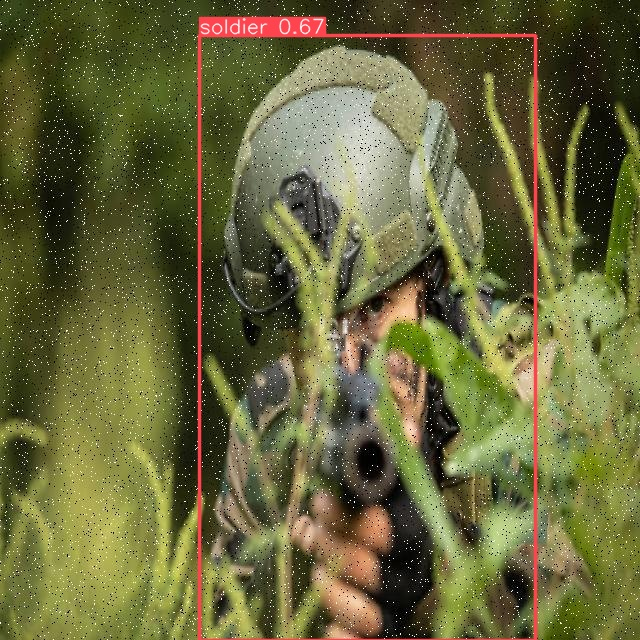

In [26]:
# Inference results visualization example
Image(
    filename=r'C:\Users\user\Documents\Reinaldo\ObjectDetection_Reinaldo\runs\detect\predict\013496.jpg'
)

In [ ]:
from pathlib import Path
from collections import Counter
import yaml

# =====================================================
# YAML
# =====================================================

yaml_file = "dataset/military_object_dataset/military_dataset.yaml"

with open(yaml_file, "r") as f:
    data = yaml.safe_load(f)

root = Path(data["path"])

splits = {
    "TRAIN": root / data["train"].replace("images", "labels"),
    "VALID": root / data["val"].replace("images", "labels"),
    "TEST":  root / data["test"].replace("images", "labels"),
}

names = data["names"]


# =====================================================
# COUNT
# =====================================================

for split_name, folder in splits.items():

    print("\n" + "="*60)
    print(split_name)
    print(folder)
    print("="*60)

    txt_files = sorted(folder.glob("*.txt"))

    print(f"Label files: {len(txt_files)}")

    object_counter = Counter()

    image_counter = Counter()

    for txt in txt_files:

        classes_in_image = set()

        with open(txt, "r") as f:

            for line in f:

                line = line.strip()

                if line == "":
                    continue

                cls = int(line.split()[0])

                object_counter[cls] += 1
                classes_in_image.add(cls)

        for cls in classes_in_image:
            image_counter[cls] += 1

    print(f"\n{'ID':<3} {'Class':<22} {'Images':>8} {'Objects':>10}")

    for cls in range(len(names)):

        print(
            f"{cls:<3} "
            f"{names[cls]:<22} "
            f"{image_counter[cls]:>8} "
            f"{object_counter[cls]:>10}"
        )

In [ ]:
# Validation and Metrics

# ============================================================
# VALIDATION
# ============================================================

val_results = model.val(
    data="dataset/military_object_dataset/military_dataset.yaml",
    split="test"
)

# ============================================================
# AUTOMATIC VALIDATION DIRECTORY
# ============================================================

val_dir = val_results.save_dir

print(f"\nSaving plots to: {val_dir}")

# ============================================================
# GLOBAL METRICS
# ============================================================

mAP50 = val_results.box.map50
mAP50_95 = val_results.box.map
mAR = np.mean(val_results.box.r)

print("\n================ GLOBAL METRICS ================\n")

print(f"mAP50       : {mAP50:.4f}")
print(f"mAP50-95    : {mAP50_95:.4f}")
print(f"mAR         : {mAR:.4f}")

# ============================================================
# PER-CLASS METRICS
# ============================================================

AP50 = val_results.box.ap50
AP50_95 = val_results.box.ap
AR = val_results.box.r

# ============================================================
# CLASS INDICES RETURNED BY ULTRALYTICS
# ============================================================

ap_class_idx = val_results.box.ap_class_index

# ============================================================
# CLASS NAMES
# ============================================================

class_names = [
    model.names[idx]
    for idx in ap_class_idx
]

# ============================================================
# REMOVE CLASSES NOT USED IN ANALYSIS
# ============================================================

excluded_classes = ["trench"
]

keep = [
    i for i, name in enumerate(class_names)
    if name not in excluded_classes
]

class_names = [class_names[i] for i in keep]

AP50 = AP50[keep]
AP50_95 = AP50_95[keep]
AR = AR[keep]

num_classes = len(class_names)

# ============================================================
# PRINT PER-CLASS METRICS
# ============================================================

print("\n================ PER-CLASS METRICS ================\n")

for i in range(num_classes):

    print(
        f"{class_names[i]:25s}"
        f" AP50: {AP50[i]:.4f}"
        f" | AP50-95: {AP50_95[i]:.4f}"
        f" | AR: {AR[i]:.4f}"
    )

# ============================================================
# AP50 PER CLASS
# ============================================================

plt.figure(figsize=(14,5))

plt.bar(class_names, AP50)

plt.axhline(
    y=mAP50,
    linestyle="--",
    label=f"Global mAP50 = {mAP50:.3f}"
)

plt.xticks(rotation=45)

plt.ylabel("AP50")

plt.title("AP50 per Class")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(val_dir, "AP50_per_class.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# AP50-95 PER CLASS
# ============================================================

plt.figure(figsize=(14,5))

plt.bar(class_names, AP50_95)

plt.axhline(
    y=mAP50_95,
    linestyle="--",
    label=f"Global mAP50-95 = {mAP50_95:.3f}"
)

plt.xticks(rotation=45)

plt.ylabel("AP50-95")

plt.title("AP50-95 per Class")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(val_dir, "AP50_95_per_class.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# AR PER CLASS
# ============================================================

plt.figure(figsize=(14,5))

plt.bar(class_names, AR)

plt.axhline(
    y=mAR,
    linestyle="--",
    label=f"Global mAR = {mAR:.3f}"
)

plt.xticks(rotation=45)

plt.ylabel("AR")

plt.title("AR per Class")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(val_dir, "AR_per_class.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FINAL MESSAGE
# ============================================================

print("\nPlots successfully saved to:")
print(val_dir)